In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

In [ ]:
# Load the heart disease dataset
df = pd.read_csv("heart.csv")

# Display the first five rows
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [3]:
# Display the dataset dimensions
print("Dataset shape:", df.shape)

# Display column names and data types
print(df.info())

# Check missing values
print(df.isnull().sum())

# Check duplicate records
print("Duplicate rows:", df.duplicated().sum())

# Generate descriptive statistics
print(df.describe())

# Examine the target classes
print(df["target"].value_counts())

Dataset shape: (303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target 

In [4]:
# Remove duplicate rows
df = df.drop_duplicates().copy()

# Display the updated dataset dimensions
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (302, 14)


In [5]:
# Convert confirmed missing-value placeholders to NaN
df["ca"] = df["ca"].replace(4, np.nan)
df["thal"] = df["thal"].replace(0, np.nan)

# Check the updated missing-value counts
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


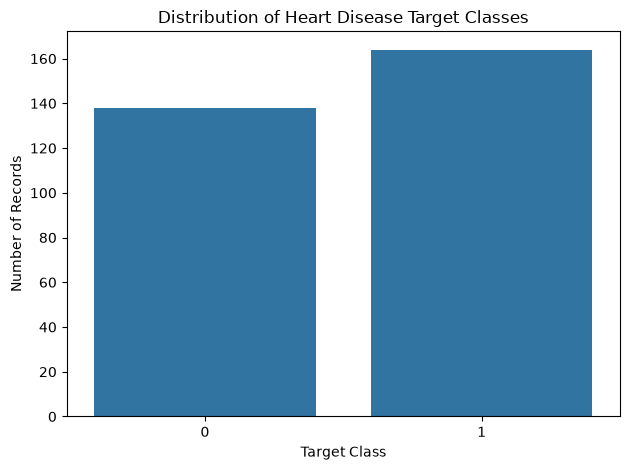

In [6]:
# Plot the number of observations in each target class
sns.countplot(data=df, x="target")

plt.title("Distribution of Heart Disease Target Classes")
plt.xlabel("Target Class")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

In [7]:
# Separate the input features from the target variable
X = df.drop(columns=["target"])
y = df["target"]

print("Input features:", X.shape)
print("Target values:", y.shape)

Input features: (302, 13)
Target values: (302,)


In [8]:
# Split the data while preserving the class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 241
Testing records: 61


In [9]:
# Identify numerical and categorical features
numeric_features = [
    "age", "trestbps", "chol", "thalach", "oldpeak"
]

categorical_features = [
    "sex", "cp", "fbs", "restecg", "exang",
    "slope", "ca", "thal"
]

# Prepare numerical features
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Prepare categorical features
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both preprocessing pipelines
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [10]:
# Combine preprocessing and Logistic Regression
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

# Train the model using only the training data
model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [11]:
# Predict the target classes for the test data
y_pred = model.predict(X_test)

# Calculate predicted probabilities for class 1
y_prob = model.predict_proba(X_test)[:, 1]

print("Actual values:", y_test.to_numpy()[:10])
print("Predicted values:", y_pred[:10])

Actual values: [0 0 0 0 0 0 1 0 1 0]
Predicted values: [0 0 0 1 0 0 1 0 1 0]


In [12]:
# Calculate the main classification metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

# Display precision, recall, and F1-score for each class
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy:  0.836
Precision: 0.829
Recall:    0.879
F1-score:  0.853

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.79      0.81        28
           1       0.83      0.88      0.85        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61



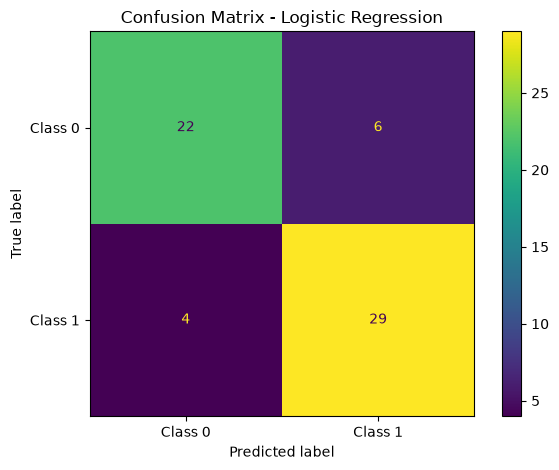

In [13]:
# Calculate and display the confusion matrix
cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"]
)

display.plot(values_format="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()

# Save the graph for the final report
plt.savefig(
    "visualizations/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\Prinson Jose J\AppData\Local\Temp\ipykernel_10280\777035320.py:19: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(


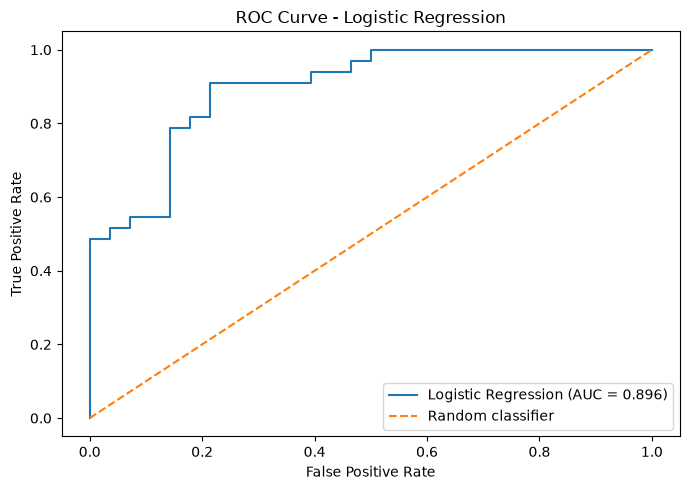

ROC-AUC: 0.896


In [14]:
# Calculate ROC curve coordinates
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate the Area Under the ROC Curve
roc_auc = roc_auc_score(y_test, y_prob)

# Plot the ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.tight_layout()

# Save the graph for the report
plt.savefig(
    "visualizations/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"ROC-AUC: {roc_auc:.3f}")